<a href="https://colab.research.google.com/github/Adyan213/Hands-On-ML/blob/main/Chapter_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from pathlib import Path
import pandas as pd
import tarfile
import urllib.request

def load_housing_data():
  tarball_path=Path("datasets/housing.tgz")
  if not tarball_path.is_file():
    Path("datasets").mkdir(parents=True, exist_ok=True)
    url="https://github.com/ageron/data/raw/main/housing.tgz"
    urllib.request.urlretrieve(url,tarball_path)
    with tarfile.open(tarball_path) as housing_tarball:
      housing_tarball.extractall(path="datasets")
  return pd.read_csv(Path("datasets/housing/housing.csv"))

housing=load_housing_data()
housing.head()

/tmp/ipython-input-3900354617.py:13: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  housing_tarball.extractall(path="datasets")


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [ ]:
housing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [ ]:
housing['ocean_proximity'].value_counts()

,count
ocean_proximity,
<1H OCEAN,9136
INLAND,6551
NEAR OCEAN,2658
NEAR BAY,2290
ISLAND,5


In [ ]:
housing.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [ ]:
import matplotlib.pyplot as plt

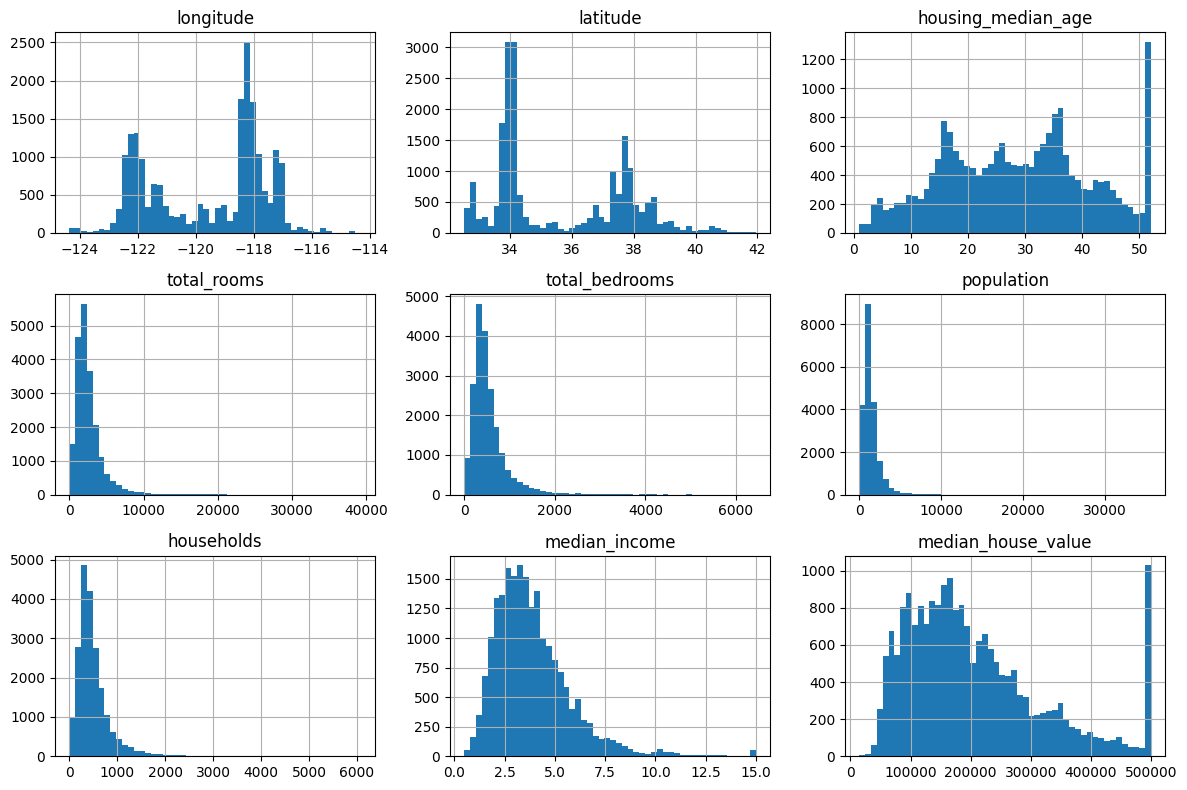

In [ ]:
housing.hist(bins=50, figsize=(12, 8))
plt.tight_layout()

In [ ]:
import numpy as np

def shuffle_and_split_data(data, test_ratio):
  shuffled_indices=np.random.permutation(len(data))
  test_set_size=int(test_ratio*len(data))
  test_indices=shuffled_indices[:test_set_size]
  train_indices=shuffled_indices[test_set_size:]
  return data.iloc[train_indices], data.iloc[test_indices]

In [ ]:
train_set, test_set=shuffle_and_split_data(housing, 0.2)

In [ ]:
len(train_set)

16512

In [ ]:
len(test_set)

4128

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
train_set, test_set=train_test_split(housing, test_size=0.2, random_state=42)

In [ ]:
housing["income_cat"]=pd.cut(housing['median_income'],
                               bins=[0, 1.5, 3, 4.5, 6, np.inf],
                               labels=[1,2,3,4,5])

Text(0, 0.5, 'Number of districts')

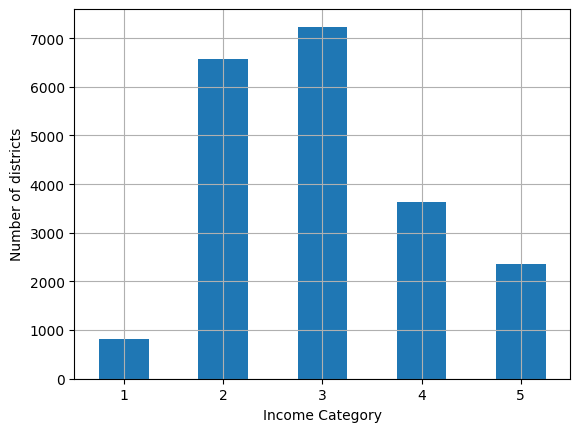

In [ ]:
housing['income_cat'].value_counts().sort_index().plot.bar(rot=0, grid=True)
plt.xlabel("Income Category")
plt.ylabel("Number of districts")

In [ ]:
from sklearn.model_selection import StratifiedShuffleSplit

splitter=StratifiedShuffleSplit(n_splits=10, test_size=0.2, random_state=42)
strat_splits=[]
for train_index, test_index in splitter.split(housing, housing['income_cat']):
  strat_train_set=housing.loc[train_index]
  strat_test_set=housing.loc[test_index]
  strat_splits.append((strat_train_set, strat_test_set))

# or
#strat_train_set, strat_test_set=train_test_split(housing, test_size=0.2, stratify=housing['income_cat'], random_state=42)

In [ ]:
strat_train_set, strat_test_set=strat_splits[0]

In [ ]:
strat_test_set['income_cat'].value_counts()/len(strat_test_set)

,count
income_cat,
3,0.350533
2,0.318798
4,0.176357
5,0.114341
1,0.039971


In [ ]:
for set_ in (strat_train_set, strat_test_set):
  set_.drop("income_cat", axis=1, inplace=True)

In [ ]:
housing=strat_train_set.copy()

<Axes: xlabel='longitude', ylabel='latitude'>

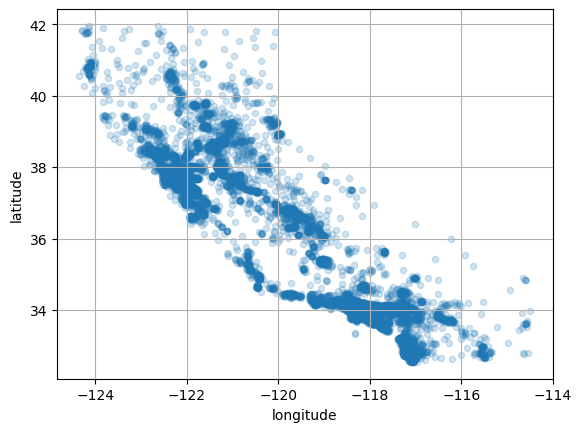

In [ ]:
housing.plot(kind="scatter", x="longitude", y="latitude", grid=True, alpha=0.2)

<Axes: xlabel='longitude', ylabel='latitude'>

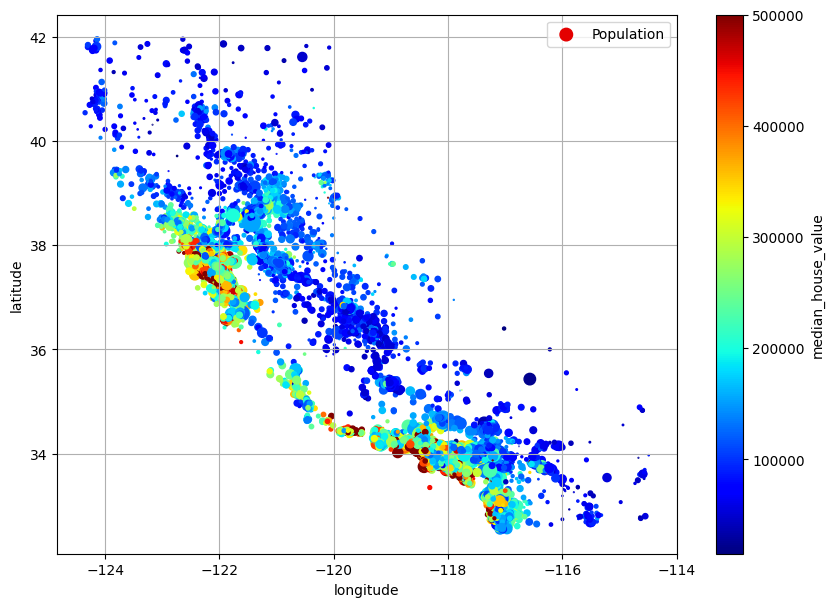

In [ ]:
housing.plot(
    kind="scatter", x="longitude", y="latitude", grid=True,
    s=housing["population"]/100, label="Population",
    c="median_house_value", cmap="jet", colorbar=True,
    legend=True, sharex=False, figsize=(10,7)
)

In [ ]:
corr_matrix=housing.corr(numeric_only=True)

In [ ]:
corr_matrix["median_house_value"].sort_values()

,median_house_value
latitude,-0.139584
longitude,-0.050859
population,-0.020153
total_bedrooms,0.054635
households,0.071426
housing_median_age,0.102175
total_rooms,0.137455
median_income,0.688380
median_house_value,1.000000


array([[<Axes: xlabel='median_house_value', ylabel='median_house_value'>,
        <Axes: xlabel='median_income', ylabel='median_house_value'>,
        <Axes: xlabel='total_rooms', ylabel='median_house_value'>,
        <Axes: xlabel='housing_median_age', ylabel='median_house_value'>],
       [<Axes: xlabel='median_house_value', ylabel='median_income'>,
        <Axes: xlabel='median_income', ylabel='median_income'>,
        <Axes: xlabel='total_rooms', ylabel='median_income'>,
        <Axes: xlabel='housing_median_age', ylabel='median_income'>],
       [<Axes: xlabel='median_house_value', ylabel='total_rooms'>,
        <Axes: xlabel='median_income', ylabel='total_rooms'>,
        <Axes: xlabel='total_rooms', ylabel='total_rooms'>,
        <Axes: xlabel='housing_median_age', ylabel='total_rooms'>],
       [<Axes: xlabel='median_house_value', ylabel='housing_median_age'>,
        <Axes: xlabel='median_income', ylabel='housing_median_age'>,
        <Axes: xlabel='total_rooms', ylabel='housi

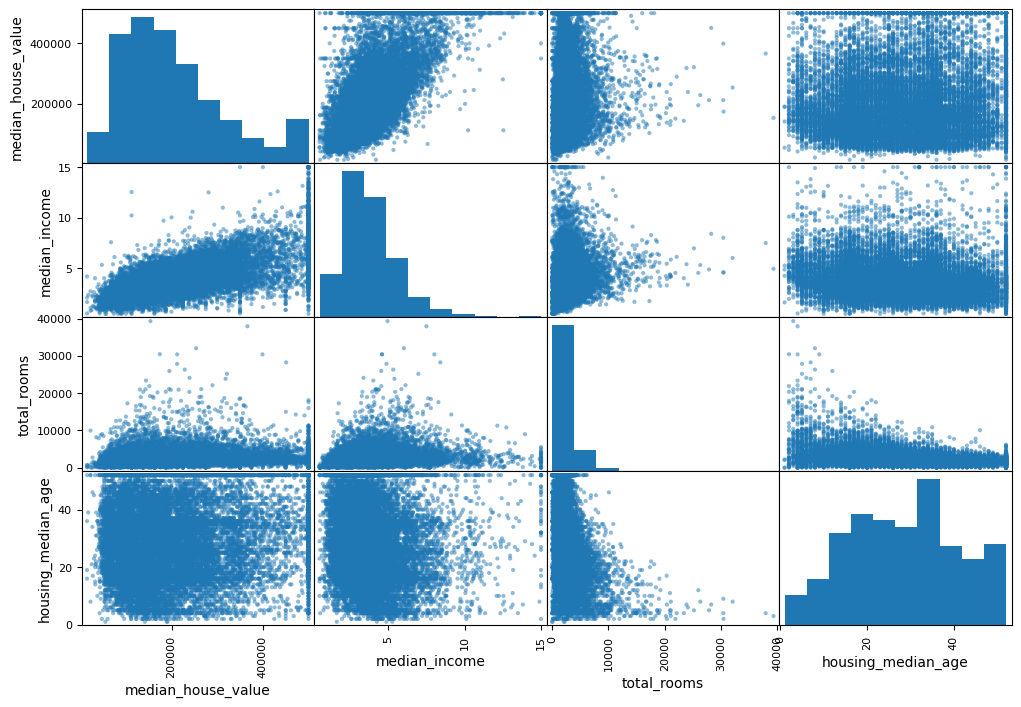

In [ ]:
from pandas.plotting import scatter_matrix

attributes=["median_house_value", "median_income", "total_rooms", "housing_median_age"]
scatter_matrix(housing[attributes], figsize=(12, 8))

<Axes: xlabel='median_income', ylabel='median_house_value'>

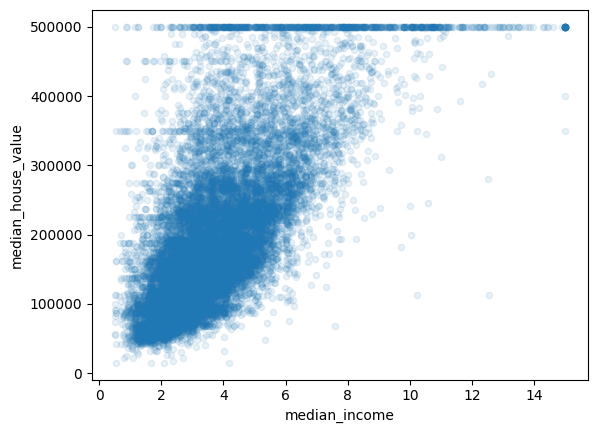

In [ ]:
housing.plot(kind="scatter", x="median_income", y="median_house_value", alpha=0.1)

In [ ]:
housing["rooms_per_house"] = housing["total_rooms"] / housing["households"]
housing["bedrooms_ratio"] = housing["total_bedrooms"] / housing["total_rooms"]
housing["people_per_house"] = housing["population"] / housing["households"]

In [ ]:
corr_matrix = housing.corr(numeric_only=True)
corr_matrix["median_house_value"].sort_values(ascending=False)

,median_house_value
median_house_value,1.000000
median_income,0.688380
rooms_per_house,0.143663
total_rooms,0.137455
housing_median_age,0.102175
households,0.071426
total_bedrooms,0.054635
population,-0.020153
people_per_house,-0.038224
longitude,-0.050859


In [ ]:
housing=strat_train_set.drop("median_house_value", axis=1)
housing_labels=strat_train_set["median_house_value"].copy()

In [ ]:
from sklearn.impute import SimpleImputer
imputer=SimpleImputer(strategy="median")

In [ ]:
housing_num=housing.select_dtypes(include=[np.number])

In [ ]:
imputer.fit(housing_num)

SimpleImputer(strategy='median')

In [ ]:
X=imputer.transform(housing_num)

In [ ]:
housing_tr=pd.DataFrame(X, columns=housing_num.columns, index=housing_num.index)

In [ ]:
housing_cat=housing[["ocean_proximity"]]

In [ ]:
housing_cat.head(8)

,ocean_proximity
13096,NEAR BAY
14973,<1H OCEAN
3785,INLAND
14689,INLAND
20507,NEAR OCEAN
1286,INLAND
18078,<1H OCEAN
4396,NEAR BAY


In [ ]:
from sklearn.preprocessing import OrdinalEncoder
ordinal_encoder=OrdinalEncoder()
housing_cat_encoded=ordinal_encoder.fit_transform(housing_cat)

housing_cat_encoded[:8]

array([[3.],
       [0.],
       [1.],
       [1.],
       [4.],
       [1.],
       [0.],
       [3.]])

In [ ]:
ordinal_encoder.categories_

[array(['<1H OCEAN', 'INLAND', 'ISLAND', 'NEAR BAY', 'NEAR OCEAN'],
       dtype=object)]

In [ ]:
from sklearn.preprocessing import OneHotEncoder
cat_encoder=OneHotEncoder()
housing_cat_1hot=cat_encoder.fit_transform(housing_cat)
housing_cat_1hot.toarray()

array([[0., 0., 0., 1., 0.],
       [1., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0.],
       ...,
       [0., 0., 0., 0., 1.],
       [1., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1.]])

In [ ]:
df_output=pd.DataFrame(housing_cat_1hot.toarray(), columns=cat_encoder.get_feature_names_out())

In [ ]:
df_output.head()

,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,0.0,0.0,0.0,1.0,0.0
1,1.0,0.0,0.0,0.0,0.0
2,0.0,1.0,0.0,0.0,0.0
3,0.0,1.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,1.0


In [ ]:
from sklearn.preprocessing import MinMaxScaler
min_max_scaler=MinMaxScaler()
housing_num_min_max_scaled=min_max_scaler.fit_transform(housing_num)

In [ ]:
from sklearn.preprocessing import StandardScaler
std_scaler=StandardScaler()
housing_num_std_scaled=std_scaler.fit_transform(housing_num)

In [ ]:
from sklearn.linear_model import LinearRegression
target_scaler=StandardScaler()
scaled_labels=target_scaler.fit_transform(housing_labels.to_frame())

In [ ]:
model=LinearRegression()
model.fit(housing[['median_income']], scaled_labels)
some_new_data=housing[["median_income"]].iloc[:5]  # Pretend this is some new data

In [ ]:
scaled_predictions=model.predict(some_new_data)
predictions=target_scaler.inverse_transform(scaled_predictions)

In [ ]:
from sklearn.compose import TransformedTargetRegressor

In [ ]:
model=TransformedTargetRegressor(
    LinearRegression(),
    transformer=StandardScaler()
)
model.fit(housing[["median_income"]], housing_labels)
predictions=model.predict(some_new_data)

In [ ]:
from sklearn.preprocessing import FunctionTransformer

In [ ]:
log_transformer=FunctionTransformer(np.log, inverse_func=np.exp)
log_pop=log_transformer.transform(housing[["population"]])

In [ ]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.utils.validation import check_array, check_is_fitted

In [ ]:
class StandardScalerClone(BaseEstimator, TransformerMixin):
  def __init__(self, with_mean=True):
    self.with_mean=with_mean

  def fit(self, y=None):
    X=check_array(X) #checks if X is an array with finite float values
    self.mean_=X.mean(axis=0)
    self.scale_=X.std(axis=0)
    self.n_features_in_=X.shape[1]  #every estimator stores this in fit
    return self

  def transform(self, X):
    check_is_fitted(self)
    X=check_array(X)
    assert self.n_features_in_==X.shape[1]
    if self.with_mean:
      X=X-self.mean_
    return X/self.scale_

In [ ]:
import sklearn

In [ ]:
sklearn.set_config(display="diagram")

In [ ]:
from sklearn.pipeline import Pipeline

In [ ]:
num_pipeline=Pipeline(
    [
        ("imputer", SimpleImputer(strategy="median")),
        ("standardize", StandardScaler()),
    ]
)

In [ ]:
housing_num_prepared=num_pipeline.fit_transform(housing_num)
housing_num_prepared[:2].round(2)

array([[-1.42,  1.01,  1.86,  0.31,  1.37,  0.14,  1.39, -0.94],
       [ 0.6 , -0.7 ,  0.91, -0.31, -0.44, -0.69, -0.37,  1.17]])

In [ ]:
df_housing_num_prepared=pd.DataFrame(
    housing_num_prepared,columns=num_pipeline.get_feature_names_out(), index=housing_num.index
)

In [ ]:
from sklearn.compose import ColumnTransformer

In [ ]:
num_attribs=["longitude", "latitude", "housing_median_age", "total_rooms", "total_bedrooms", "population", "households", "median_income"]
cat_attribs=["ocean_proximity"]

In [ ]:
from sklearn.pipeline import make_pipeline
cat_pipeline=make_pipeline(
    SimpleImputer(strategy="most_frequent"),
    OneHotEncoder(handle_unknown="ignore")
)

In [ ]:
preprocessing=ColumnTransformer(
    [
        ("num", num_pipeline, num_attribs),
        ("cat", cat_pipeline, cat_attribs),
    ]
)

In [ ]:
from sklearn.compose import make_column_transformer, make_column_selector

In [ ]:
preprocessing = make_column_transformer(
    (num_pipeline, make_column_selector(dtype_include=np.number)),
    (cat_pipeline, make_column_selector(dtype_include=object)),
)
housing_prepared=preprocessing.fit_transform(housing)

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import rbf_kernel

class ClusterSimilarity(BaseEstimator, TransformerMixin):
    def __init__(self, n_clusters=10, gamma=1.0, random_state=None):
        self.n_clusters = n_clusters
        self.gamma = gamma
        self.random_state = random_state

    def fit(self, X, y=None, sample_weight=None):
        self.kmeans_ = KMeans(self.n_clusters, n_init=10,
                              random_state=self.random_state)
        self.kmeans_.fit(X, sample_weight=sample_weight)
        return self  # always return self!

    def transform(self, X):
        return rbf_kernel(X, self.kmeans_.cluster_centers_, gamma=self.gamma)

    def get_feature_names_out(self, names=None):
        return [f"Cluster {i} similarity" for i in range(self.n_clusters)]

In [ ]:
cluster_simil = ClusterSimilarity(n_clusters=10, gamma=1., random_state=42)
similarities = cluster_simil.fit_transform(housing[["latitude", "longitude"]])

In [ ]:
def column_ratio(X):
  # Ensure X is a NumPy array for consistent indexing
  if isinstance(X, pd.DataFrame):
    X = X.values
  return X[:, [0]]/X[:, [1]]

def ratio_name(function_transformer, feature_names_in):
  return ["ratio"]

def ratio_pipeline():
  return make_pipeline(
      SimpleImputer(strategy="median"), # Added imputer here
      FunctionTransformer(column_ratio, feature_names_out=ratio_name),
      StandardScaler())

log_pipeline=make_pipeline(
    SimpleImputer(strategy="median"),
    FunctionTransformer(np.log, feature_names_out="one-to-one"),
    StandardScaler()
)

cluster_simil=ClusterSimilarity(n_clusters=10, gamma=1., random_state=42)

default_num_pipeline=make_pipeline(
    SimpleImputer(strategy="median"),
    StandardScaler()
)

preprocessing=ColumnTransformer([
    ("bedrooms", ratio_pipeline(), ["total_rooms", "total_bedrooms"]),
    ("rooms_per_house", ratio_pipeline(), ["total_rooms", "households"]),
    ("people_per_house", ratio_pipeline(), ["population", "households"]),
    ("log", log_pipeline, ["median_income", "total_bedrooms", "total_rooms", "population", "households"]),
    ("geo", cluster_simil, ["latitude", "longitude"]),
    ("cat", cat_pipeline, make_column_selector(dtype_include=object)),
],
remainder=default_num_pipeline)

In [ ]:
housing_prepared=preprocessing.fit_transform(housing)

In [ ]:
housing_prepared.shape

(16512, 24)

In [ ]:
preprocessing.get_feature_names_out()

array(['bedrooms__ratio', 'rooms_per_house__ratio',
       'people_per_house__ratio', 'log__median_income',
       'log__total_bedrooms', 'log__total_rooms', 'log__population',
       'log__households', 'geo__Cluster 0 similarity',
       'geo__Cluster 1 similarity', 'geo__Cluster 2 similarity',
       'geo__Cluster 3 similarity', 'geo__Cluster 4 similarity',
       'geo__Cluster 5 similarity', 'geo__Cluster 6 similarity',
       'geo__Cluster 7 similarity', 'geo__Cluster 8 similarity',
       'geo__Cluster 9 similarity', 'cat__ocean_proximity_<1H OCEAN',
       'cat__ocean_proximity_INLAND', 'cat__ocean_proximity_ISLAND',
       'cat__ocean_proximity_NEAR BAY', 'cat__ocean_proximity_NEAR OCEAN',
       'remainder__housing_median_age'], dtype=object)

In [ ]:
lin_reg=make_pipeline(preprocessing, LinearRegression())
lin_reg.fit(housing, housing_labels)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder=Pipeline(steps=[('simpleimputer',
                                                              SimpleImputer(strategy='median')),
                                                             ('standardscaler',
                                                              StandardScaler())]),
                                   transformers=[('bedrooms',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('functiontransformer',
                                                                   FunctionTransformer(feature_names_out=<function ratio_name at 0x7f9...
                                                   'total_rooms', 'population',
                                                   'households']),
                                                 ('geo',
                                                  ClusterSimilarity(random_state=42),
                                                  ['latitude', 'longitude']),
                                                 ('cat',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehotencoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x7f947de26420>)])),
                ('linearregression', LinearRegression())])

In [ ]:
housing_predictions=lin_reg.predict(housing)

In [ ]:
housing_predictions[:5].round(-2)

array([254500., 370200., 123700.,  96200., 325800.])

In [ ]:
housing_labels.iloc[:5].values

array([458300., 483800., 101700.,  96100., 361800.])

In [ ]:
from sklearn.metrics import root_mean_squared_error

In [ ]:
lin_rmse=root_mean_squared_error(housing_labels, housing_predictions)
lin_rmse

67585.93989048962

In [ ]:
from sklearn.tree import DecisionTreeRegressor

In [ ]:
tree_reg=make_pipeline(preprocessing, DecisionTreeRegressor(random_state=42))
tree_reg.fit(housing, housing_labels)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder=Pipeline(steps=[('simpleimputer',
                                                              SimpleImputer(strategy='median')),
                                                             ('standardscaler',
                                                              StandardScaler())]),
                                   transformers=[('bedrooms',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('functiontransformer',
                                                                   FunctionTransformer(feature_names_out=<function ratio_name at 0x7f9...
                                                  ClusterSimilarity(random_state=42),
                                                  ['latitude', 'longitude']),
                                                 ('cat',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehotencoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x7f947de26420>)])),
                ('decisiontreeregressor',
                 DecisionTreeRegressor(random_state=42))])

In [ ]:
housing_predictions=tree_reg.predict(housing)
tree_rmse=root_mean_squared_error(housing_labels, housing_predictions)
tree_rmse

0.0

In [ ]:
from sklearn.model_selection import cross_val_score

In [ ]:
tree_rmses=-cross_val_score(tree_reg, housing, housing_labels,
                           scoring="neg_root_mean_squared_error", cv=10)

In [ ]:
pd.Series(tree_rmses).describe()

,0
count,10.000000
mean,66610.346534
std,1733.723372
min,64019.873489
25%,65487.941691
50%,66345.365531
75%,67752.468205
max,69571.458624


In [ ]:
from sklearn.ensemble import RandomForestRegressor

In [ ]:
forest_reg=make_pipeline(preprocessing, RandomForestRegressor(n_estimators=100, random_state=42))
forest_rmses=-cross_val_score(forest_reg, housing, housing_labels,
                              scoring="neg_root_mean_squared_error", cv=10)


In [ ]:
pd.Series(forest_rmses).describe()

,0
count,10.000000
mean,46922.216849
std,1056.792030
min,45469.863158
25%,46245.044888
50%,47066.295728
75%,47220.123241
max,49256.748728


In [ ]:
from sklearn.model_selection import GridSearchCV

In [ ]:
full_pipeline=Pipeline([
    ("preprocessing", preprocessing),
    ("random_forest", RandomForestRegressor(random_state=42))
])

param_grid=[
    {
        "preprocessing__geo__n_clusters": [5, 8, 10],
        "random_forest__max_features": [4, 6, 8],
    },
    {
        "preprocessing__geo__n_clusters": [10, 15],
        "random_forest__max_features": [6, 8, 10],
    }
]

grid_search=GridSearchCV(full_pipeline, param_grid, cv=3,
                         scoring="neg_root_mean_squared_error")
grid_search.fit(housing, housing_labels)

GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('preprocessing',
                                        ColumnTransformer(remainder=Pipeline(steps=[('simpleimputer',
                                                                                     SimpleImputer(strategy='median')),
                                                                                    ('standardscaler',
                                                                                     StandardScaler())]),
                                                          transformers=[('bedrooms',
                                                                         Pipeline(steps=[('simpleimputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('functiontransformer',
                                                                                          FunctionTransformer(feature_names_out=<f...
                                                                         <sklearn.compose._column_transformer.make_column_selector object at 0x7f947de26420>)])),
                                       ('random_forest',
                                        RandomForestRegressor(random_state=42))]),
             param_grid=[{'preprocessing__geo__n_clusters': [5, 8, 10],
                          'random_forest__max_features': [4, 6, 8]},
                         {'preprocessing__geo__n_clusters': [10, 15],
                          'random_forest__max_features': [6, 8, 10]}],
             scoring='neg_root_mean_squared_error')

In [ ]:
grid_search.best_estimator_

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(remainder=Pipeline(steps=[('simpleimputer',
                                                              SimpleImputer(strategy='median')),
                                                             ('standardscaler',
                                                              StandardScaler())]),
                                   transformers=[('bedrooms',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('functiontransformer',
                                                                   FunctionTransformer(feature_names_out=<function ratio_name at 0x7f947bc...
                                                  ClusterSimilarity(n_clusters=15,
                                                                    random_state=42),
                                                  ['latitude', 'longitude']),
                                                 ('cat',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehotencoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x7f947bcac320>)])),
                ('random_forest',
                 RandomForestRegressor(max_features=6, random_state=42))])

In [ ]:
cv_res=pd.DataFrame(grid_search.cv_results_)
cv_res.sort_values(by="mean_test_score", ascending=False, inplace=True)
cv_res.head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_preprocessing__geo__n_clusters,param_random_forest__max_features,params,split0_test_score,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score
12,7.199929,0.077297,0.127065,0.001242,15,6,"{'preprocessing__geo__n_clusters': 15, 'random...",-43084.213053,-43424.054995,-44270.161296,-43592.809781,498.649471,1
6,5.055591,0.049345,0.126875,0.000725,10,4,"{'preprocessing__geo__n_clusters': 10, 'random...",-43626.662299,-43914.618393,-44941.064063,-44160.781585,564.127785,2
13,8.778710,0.049947,0.126743,0.001138,15,8,"{'preprocessing__geo__n_clusters': 15, 'random...",-43695.244637,-44101.456600,-44915.493521,-44237.398253,507.353877,3
9,6.607886,0.145361,0.126286,0.001116,10,6,"{'preprocessing__geo__n_clusters': 10, 'random...",-43732.558930,-44318.554094,-45226.511681,-44425.874901,614.606661,4
7,6.768065,0.045107,0.124196,0.000503,10,6,"{'preprocessing__geo__n_clusters': 10, 'random...",-43732.558930,-44318.554094,-45226.511681,-44425.874901,614.606661,4


In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

param_distribs={
    "preprocessing__geo__n_clusters": randint(low=3, high=50),
    "random_forest__max_features": randint(low=2, high=20)
}

rnd_search=RandomizedSearchCV(full_pipeline, param_distributions=param_distribs,
                              n_iter=10, cv=3, scoring="neg_root_mean_squared_error",
                              random_state=42)
rnd_search.fit(housing, housing_labels)

RandomizedSearchCV(cv=3,
                   estimator=Pipeline(steps=[('preprocessing',
                                              ColumnTransformer(remainder=Pipeline(steps=[('simpleimputer',
                                                                                           SimpleImputer(strategy='median')),
                                                                                          ('standardscaler',
                                                                                           StandardScaler())]),
                                                                transformers=[('bedrooms',
                                                                               Pipeline(steps=[('simpleimputer',
                                                                                                SimpleImputer(strategy='median')),
                                                                                               ('functiontransformer',
                                                                                                FunctionTransformer(feature_names_...
                                             ('random_forest',
                                              RandomForestRegressor(random_state=42))]),
                   param_distributions={'preprocessing__geo__n_clusters': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7f94c5ecc200>,
                                        'random_forest__max_features': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7f9479d92e70>},
                   random_state=42, scoring='neg_root_mean_squared_error')

In [ ]:
final_model=rnd_search.best_estimator_
feature_importances=final_model["random_forest"].feature_importances_
feature_importances.round(2)

array([0.06, 0.06, 0.05, 0.19, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01,
       0.04, 0.01, 0.  , 0.02, 0.01, 0.01, 0.01, 0.01, 0.01, 0.  , 0.01,
       0.01, 0.01, 0.01, 0.02, 0.03, 0.01, 0.01, 0.02, 0.02, 0.01, 0.01,
       0.01, 0.01, 0.01, 0.01, 0.  , 0.01, 0.01, 0.01, 0.01, 0.01, 0.02,
       0.01, 0.01, 0.01, 0.01, 0.02, 0.02, 0.01, 0.01, 0.01, 0.  , 0.07,
       0.  , 0.  , 0.  , 0.01])

In [ ]:
sorted(zip(feature_importances,
           final_model["preprocessing"].get_feature_names_out()),
       reverse=True)

[(np.float64(0.19081350599324623), 'log__median_income'),
 (np.float64(0.07432901648914636), 'cat__ocean_proximity_INLAND'),
 (np.float64(0.06167722929783779), 'bedrooms__ratio'),
 (np.float64(0.0551280789121785), 'rooms_per_house__ratio'),
 (np.float64(0.050359280273452926), 'people_per_house__ratio'),
 (np.float64(0.03665064729665029), 'geo__Cluster 3 similarity'),
 (np.float64(0.02685293217905122), 'geo__Cluster 18 similarity'),
 (np.float64(0.022389010828056808), 'geo__Cluster 17 similarity'),
 (np.float64(0.021442688555760658), 'geo__Cluster 22 similarity'),
 (np.float64(0.01896857962691899), 'geo__Cluster 40 similarity'),
 (np.float64(0.018113347512827217), 'geo__Cluster 21 similarity'),
 (np.float64(0.017792011793326835), 'geo__Cluster 41 similarity'),
 (np.float64(0.015418568746280168), 'geo__Cluster 35 similarity'),
 (np.float64(0.015073047406678088), 'geo__Cluster 6 similarity'),
 (np.float64(0.014863433801146735), 'geo__Cluster 32 similarity'),
 (np.float64(0.014370223862927

In [ ]:
X_test=strat_test_set.drop("median_house_value", axis=1)
y_test=strat_test_set["median_house_value"].copy()

final_predictions=final_model.predict(X_test)

final_rmse=root_mean_squared_error(y_test, final_predictions)
print(final_rmse)

41716.16277382123


In [ ]:
from scipy import stats

def rmse(squared_errors):
  return np.sqrt(np.mean(squared_errors))

confidence=0.95
squared_errors=(final_predictions-y_test)**2
boot_result=stats.bootstrap([squared_errors], rmse, confidence_level=confidence, random_state=42)
rmse_lower, rmse_higher=boot_result.confidence_interval
print(rmse_lower, rmse_higher)

39769.76781800474 44000.734464493085


In [ ]:
import joblib

joblib.dump(final_model, "my_california_housing_model.pkl")

['my_california_housing_model.pkl']

In [ ]:
final_model_reloaded=joblib.load("my_california_housing_model.pkl")


In [ ]:
X_test.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity
3905,-121.95,37.11,21.0,2387.0,357.0,913.0,341.0,7.7360,<1H OCEAN
16821,-118.01,33.89,36.0,1589.0,265.0,804.0,272.0,4.6354,<1H OCEAN
2900,-118.18,33.74,30.0,5915.0,1750.0,2136.0,1503.0,4.0968,NEAR OCEAN
7193,-122.48,37.74,52.0,2166.0,423.0,1072.0,370.0,4.1310,NEAR OCEAN
13928,-122.39,37.78,5.0,1405.0,515.0,725.0,392.0,3.6037,NEAR BAY


In [ ]:
import pandas as pd
input_data=pd.DataFrame([{"longitude":-121,"latitude":37,"housing_median_age":21,
                                          "total_rooms":2387,"total_bedrooms":367,
                                          "population":915,"households":345,"median_income":8,
                                          "ocean_proximity":"NEAR OCEAN"}])
predictions=final_model_reloaded.predict(input_data)
print(predictions)

[298015.11]
